In [1]:
import copy
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from parnassus.torch_delphes import param_config as pc
from parnassus.torch_delphes.defaults import CMSEnergyFlowDefault
from parnassus.torch_delphes.tune_cms_fullsim.data import (
    load_cms_flow_root,
    load_truth_events,
    load_pflow_targets,
    restore_event_format,
    load_pflow_targets_from_tensor,
)
from parnassus.torch_delphes.tune_cms_fullsim.dataloader import DelphesDataSet, DelphesDataLoader
from parnassus.torch_delphes.tune_cms_fullsim.loss import per_event_wasserstein_loss
from parnassus.torch_delphes.tune_cms_fullsim.config import OBSERVABLES

# ----------------------------------------------------------------------------
# Paths. The notebook lives in <repo>/notebooks, so the repo root is its parent.
# ----------------------------------------------------------------------------
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ROOT_FILE = REPO / "src/parnassus/tests/benchmark_data/cms_pseudodata.root"
CFG_DIR = REPO / "src/parnassus/torch_delphes/param_configs"
TRUTH_CFG = CFG_DIR / "cms_target_default.yaml"   # ground-truth parameter values
assert ROOT_FILE.exists(), ROOT_FILE
assert TRUTH_CFG.exists(), TRUTH_CFG

# ----------------------------------------------------------------------------
# Knobs
# ----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_EVENTS = -1      # -1 = all events in the file (5400)
BATCH_SIZE = 512   # same batching as tune_cms_fullsim, so the loss is comparable

# The Gumbel tracking-efficiency draws are stochastic; averaging the loss over a few
# seeds gives a noise band (the `std` column / error bars). That band matters here:
# the loss varies only slightly across this parameter, so you need it to judge whether
# a dip is real signal or just sampling noise.
SEEDS = [0, 1, 2]  # use [0] for a quick single-seed pass (~1/3 the cost, but std = 0)

print(f"device={DEVICE}  n_events={N_EVENTS}  batch_size={BATCH_SIZE}  seeds={SEEDS}")

device=cuda  n_events=-1  batch_size=512  seeds=[0, 1, 2]


In [2]:
# ----------------------------------------------------------------------------
# Load the data ONCE: truth particles (card input) + pflow target observables.
# The pseudodata's pflow was generated with the truth parameters, so the loss
# should be (near) minimal when every parameter sits at its truth value.
# ----------------------------------------------------------------------------
arrays = load_cms_flow_root(ROOT_FILE, n_events=N_EVENTS)
truth_tensor = load_truth_events(arrays)     # (n_events, max_particles, N_FEATURES), float64
target = load_pflow_targets(arrays)          # dict of fixed target observables

# shuffle=False -> fixed batch composition -> reproducible per-batch losses.
dataset = DelphesDataSet(truth_tensor, target, device=DEVICE)
loader = DelphesDataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"truth_tensor: {tuple(truth_tensor.shape)} ({truth_tensor.dtype})")
print(f"loaded {len(dataset)} events -> {len(loader)} batches of <= {BATCH_SIZE}")

truth_tensor: (5400, 1240, 20) (torch.float64)
loaded 5400 events -> 11 batches of <= 512


In [3]:
truth_cfg = pc.load_param_config(TRUTH_CFG)   # all 66 params at their truth values
truth_cfg

{'ChargedHadronTrackingEfficiency.eff_logits[0]': {'value': 0.7,
  'trainable': False,
  'lr_scale': 1.0},
 'ChargedHadronTrackingEfficiency.eff_logits[1]': {'value': 0.95,
  'trainable': False,
  'lr_scale': 1.0},
 'ChargedHadronTrackingEfficiency.eff_logits[2]': {'value': 0.6,
  'trainable': False,
  'lr_scale': 1.0},
 'ChargedHadronTrackingEfficiency.eff_logits[3]': {'value': 0.85,
  'trainable': False,
  'lr_scale': 1.0},
 'ElectronTrackingEfficiency.eff_logits[0]': {'value': 0.73,
  'trainable': False,
  'lr_scale': 1.0},
 'ElectronTrackingEfficiency.eff_logits[1]': {'value': 0.95,
  'trainable': False,
  'lr_scale': 1.0},
 'ElectronTrackingEfficiency.eff_logits[2]': {'value': 0.99,
  'trainable': False,
  'lr_scale': 1.0},
 'ElectronTrackingEfficiency.eff_logits[3]': {'value': 0.5,
  'trainable': False,
  'lr_scale': 1.0},
 'ElectronTrackingEfficiency.eff_logits[4]': {'value': 0.83,
  'trainable': False,
  'lr_scale': 1.0},
 'ElectronTrackingEfficiency.eff_logits[5]': {'value': 0

In [4]:
def build_card():
    """Fresh learnable card with every parameter initialized to its truth value."""
    card = CMSEnergyFlowDefault(debug=False, learnable=True).to(DEVICE)
    pc.apply_param_config(card, truth_cfg)
    return card


def set_config(card, overrides):
    """Set ALL parameters to truth, then override {name[i]: physical_value}.

    Rebuilding from `truth_cfg` every call guarantees that everything except the
    overridden key(s) sits exactly at truth (no leakage between evaluations).
    """
    cfg = copy.deepcopy(truth_cfg)
    for key, val in overrides.items():
        if key not in cfg:
            raise KeyError(f"{key!r} is not a known parameter (not in {TRUTH_CFG.name})")
        cfg[key] = {**cfg[key], "value": float(val)}
    pc.apply_param_config(card, cfg)


card = build_card()
print("card built; all parameters initialized to truth.")

card built; all parameters initialized to truth.


In [5]:
@torch.no_grad()
def mean_loss(card, loader, seed=0):
    """Mean per-batch Wasserstein loss over all batches (same definition as training)."""
    torch.manual_seed(seed)
    card.eval()
    total, n_batches = 0.0, 0
    for batch in loader:
        truth = batch["truth_particles"]              # (b, max_particles, n_feat)
        mask = torch.any(truth != 0, dim=-1)          # drop all-zero padded particles
        out = card(truth[mask])                       # dict with "EFlowObject"
        eflow = restore_event_format(out["EFlowObject"], mask)
        pred = load_pflow_targets_from_tensor(eflow)  # differentiable observables
        tgt = {k: v for k, v in batch.items() if k != "truth_particles"}
        total += float(per_event_wasserstein_loss(pred, tgt, OBSERVABLES))
        n_batches += 1
    return total / n_batches


def mean_loss_band(card, loader, seeds=None):
    """(mean, std) of the loss over the Gumbel seeds in `seeds` (default SEEDS)."""
    seeds = SEEDS if seeds is None else seeds
    vals = np.array([mean_loss(card, loader, s) for s in seeds])
    return float(vals.mean()), float(vals.std())


# Quick sanity check: same config + same seed must be exactly reproducible.
set_config(card, {})
_b = mean_loss(card, loader, 0)
print(f"loss(all truth) = {_b:.5f}")

loss(all truth) = 0.26953


In [6]:
def scan_loss(param, scan_range):
    means = []
    stds = []
    for value in tqdm(scan_range):
        set_config(card, {scan_param: float(value)})
        m, s = mean_loss_band(card, loader)
        means.append(m)
        stds.append(s)
    return np.array(means), np.array(stds)

100%|██████████| 21/21 [01:50<00:00,  5.27s/it]


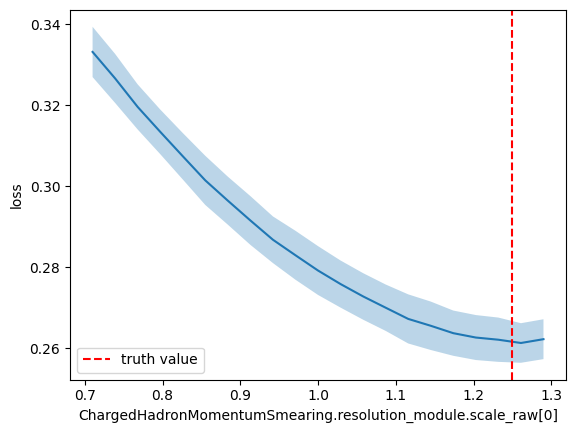

In [7]:
scan_param ="ChargedHadronMomentumSmearing.resolution_module.scale_raw[0]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 1.25

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:48<00:00,  5.17s/it]


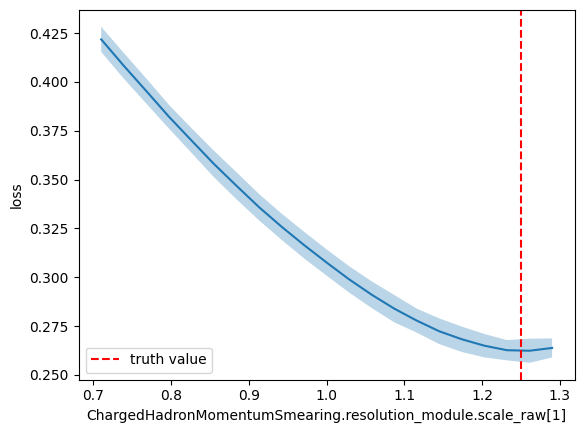

In [8]:
scan_param ="ChargedHadronMomentumSmearing.resolution_module.scale_raw[1]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 1.25

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:48<00:00,  5.19s/it]


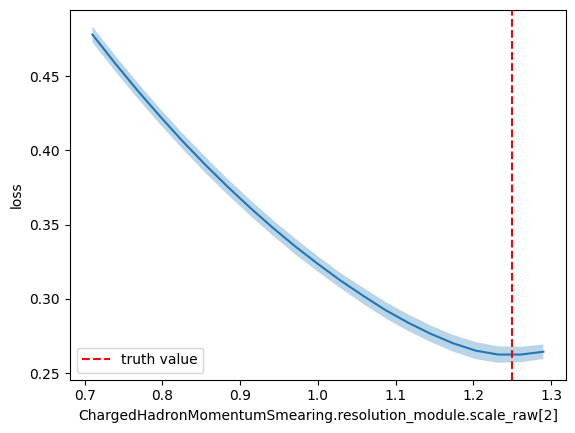

In [9]:
scan_param ="ChargedHadronMomentumSmearing.resolution_module.scale_raw[2]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 1.25

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:46<00:00,  5.09s/it]


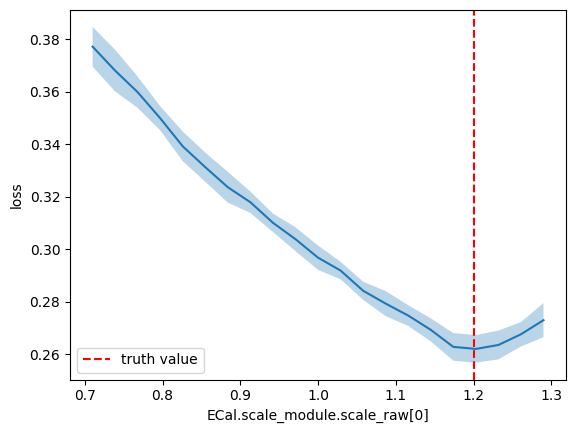

In [10]:
scan_param ="ECal.scale_module.scale_raw[0]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 1.2

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:46<00:00,  5.07s/it]


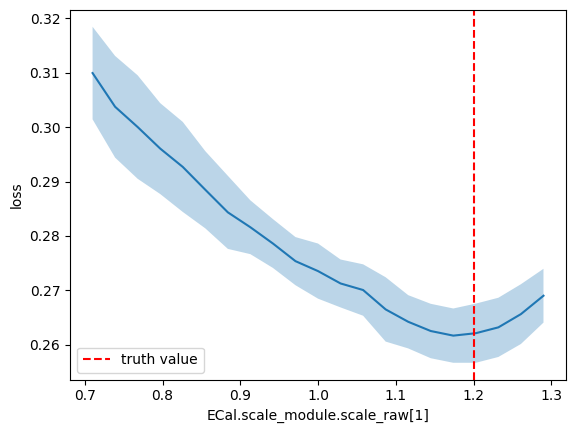

In [11]:
scan_param ="ECal.scale_module.scale_raw[1]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 1.2

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:46<00:00,  5.08s/it]


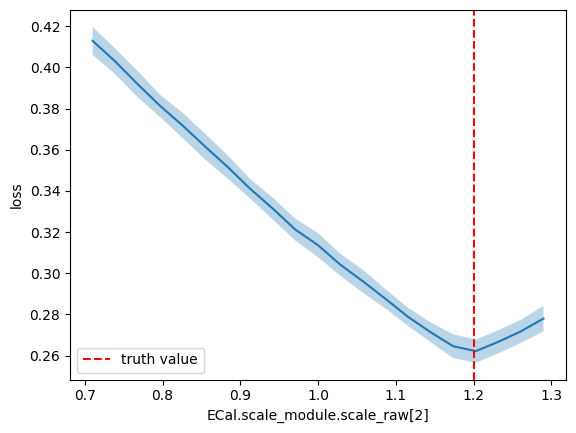

In [12]:
scan_param ="ECal.scale_module.scale_raw[2]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 1.2

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:47<00:00,  5.12s/it]


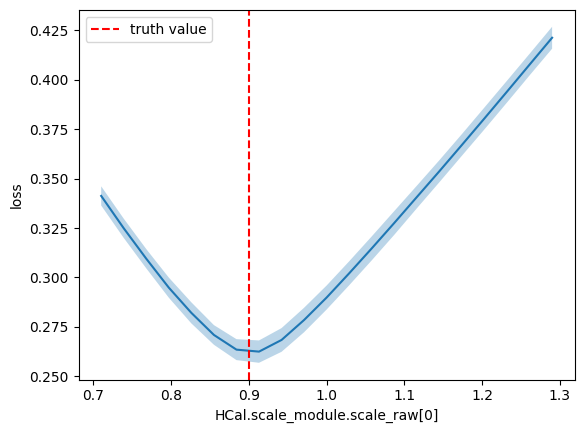

In [13]:
scan_param ="HCal.scale_module.scale_raw[0]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 0.9

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:47<00:00,  5.12s/it]


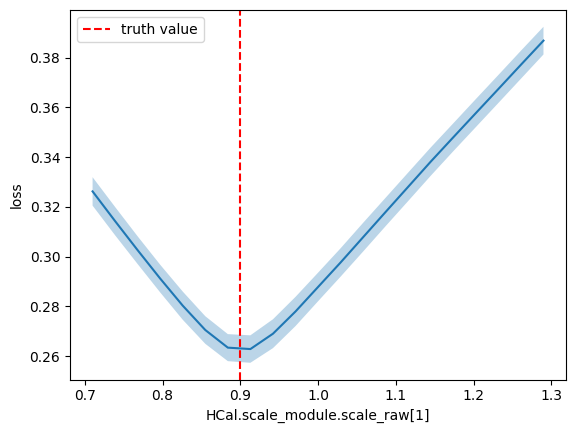

In [14]:
scan_param ="HCal.scale_module.scale_raw[1]"
scan_range = np.linspace(0.71, 1.29, 21)
truth_value = 0.9

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:46<00:00,  5.09s/it]


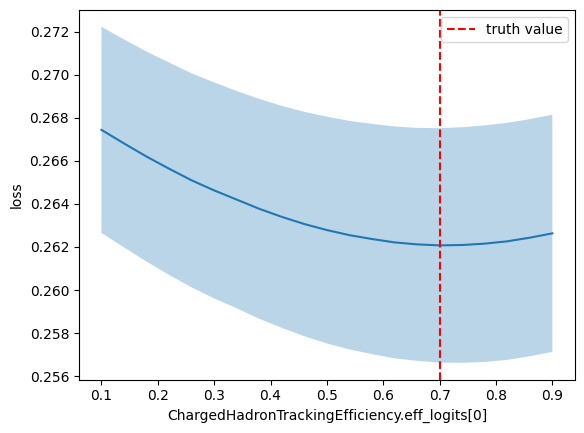

In [15]:
scan_param ="ChargedHadronTrackingEfficiency.eff_logits[0]"
scan_range = np.linspace(0.1, 0.9, 21)
truth_value = 0.7

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.legend()
plt.xlabel(f"{scan_param}")
plt.ylabel("loss")
plt.show()

100%|██████████| 41/41 [03:29<00:00,  5.10s/it]


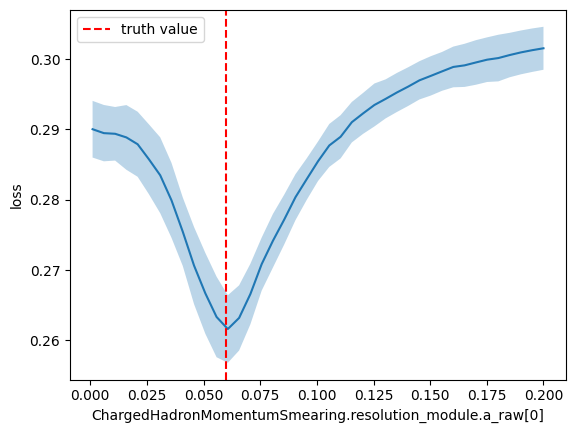

In [19]:
scan_param ="ChargedHadronMomentumSmearing.resolution_module.a_raw[0]"
scan_range = np.linspace(0.001, 0.2, 41)
truth_value = 0.06

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.xlabel(f"{scan_param}")
plt.legend()
plt.ylabel("loss")
plt.show()

100%|██████████| 21/21 [01:47<00:00,  5.11s/it]


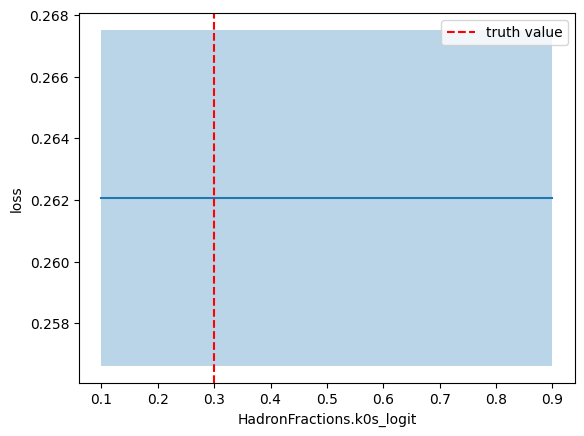

In [17]:
scan_param ="HadronFractions.k0s_logit"
scan_range = np.linspace(0.1, 0.9, 21)
truth_value = 0.3

means, stds = scan_loss(scan_param, scan_range)

f = plt.figure()
plt.plot(scan_range, means)
plt.fill_between(scan_range, means + stds, means - stds, alpha=0.3)
plt.axvline(truth_value, color="red", label="truth value", ls="--")
plt.xlabel(f"{scan_param}")
plt.legend()
plt.ylabel("loss")
plt.show()

In [18]:
means

array([0.26207346, 0.26207346, 0.26207346, 0.26207346, 0.26207346,
       0.26207346, 0.26207346, 0.26207346, 0.26207346, 0.26207346,
       0.26207346, 0.26207346, 0.26207346, 0.26207346, 0.26207346,
       0.26207346, 0.26207346, 0.26207346, 0.26207346, 0.26207346,
       0.26207346])